In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree


In [2]:
def count_value(list1:list):
    # values [ -1000,-100,-10,-1,0,1,10,100,1000]
    list1 = np.array(list1)
    cts = {"-10e3+":0, "-10e3e2":0,"-10e2e1":0, "-10e1e0":0, "-1_0":0, "1_0":0 ,"10e0e1":0, "10e1e2":0,"10e2e3":0, "10e3+":0 }
    for i in range(len(list1)):
        tv = list1[i]
        #print(tv)
        if(tv<= -1000):
            cts['-10e3+']+=1
        elif( tv>-1000 and tv<= -100):
            cts['-10e3e2'] +=1
        elif( tv>-100 and tv<= -10):
            cts['-10e2e1'] +=1
        elif( tv>-10 and tv<= -1):
            cts['-10e1e0'] +=1
        elif( tv>-1 and tv <= 0):
            cts['-1_0'] +=1
        elif( tv>0 and tv<= 1):
            cts['1_0'] +=1
        elif( tv>1 and tv<= 10):
            cts['10e0e1'] +=1
        elif( tv>10 and tv<= 100):
            cts['10e1e2'] +=1
        elif( tv>100 and tv<= 100):
            cts['10e2e3'] +=1
        else :
            cts['10e3+'] +=1

    return cts

In [3]:
f1 = '/Users/potato/Downloads/plt59000_flame_iso_c05_flamefront1024_points.csv'
f2 = '/Users/potato/Downloads/plt59250_flame_iso_c05_flamefront1024_points.csv'
df1 = pd.read_csv(f1)
df2 = pd.read_csv(f2)

In [4]:
df_sum = df2.copy()
dx = df1['x'] - df2['x']
movement = []
markers= []
for i in range(len(dx)):
    if (dx[i]>0):
        # forward
        movement.append(1)
        markers.append('<')
    elif(dx[i]<0):
        movement.append(-1)
        markers.append('>')
    else:
        movement.append(0)
        markers.append('.')
df_sum["dx"] =  dx
df_sum['displacement']=movement
df_sum['prev_curv'] = df1['curvature']
df_sum['d_curv'] = df_sum['curvature'] - df_sum['prev_curv']

In [5]:
df_f = df_sum[df_sum['displacement']==1]
df_b = df_sum[df_sum['displacement']==-1]
df_s = df_sum[df_sum['displacement']==0]
print(df_f.shape[0])
print(df_b.shape[0])
print(df_s.shape[0])

598
407
18


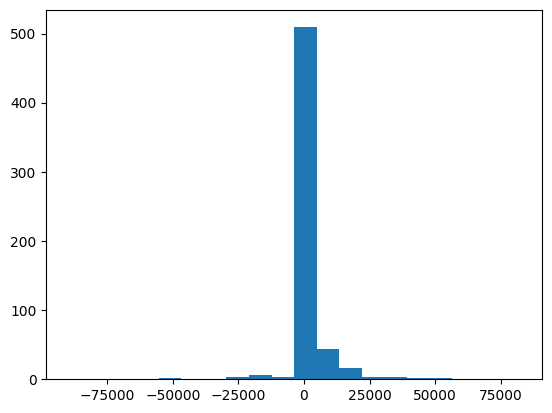

In [6]:
plt.hist(df_f['curvature'],bins=20)
plt.show()

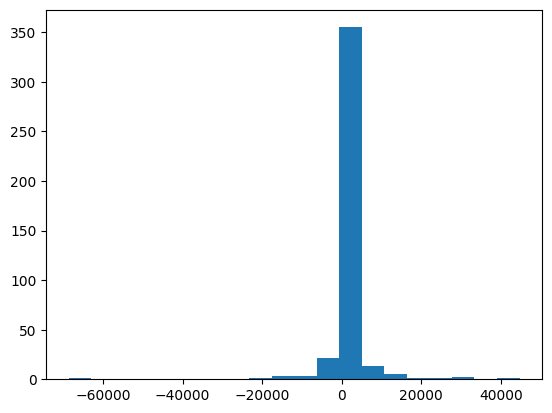

In [7]:
plt.hist(df_b['curvature'],bins=20)
plt.show()

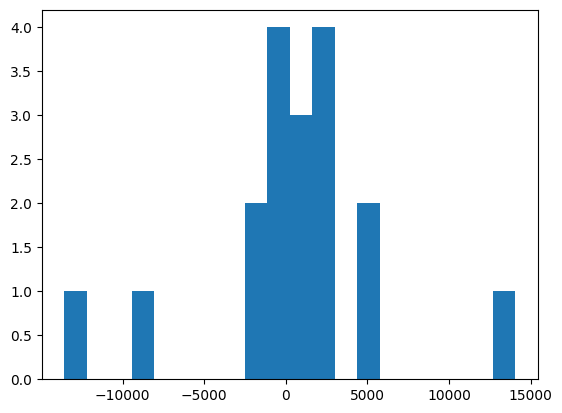

In [8]:
plt.hist(df_s['curvature'],bins=20)
plt.show()

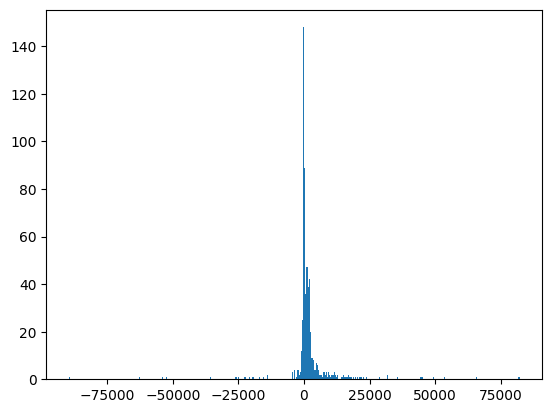

mean value of forward curvature 1743.972617086275 
median value of forward curvature 428.6705356928149 
std value of forward curvature 9644.207993429029 


In [10]:
plt.hist(df_f['curvature'],bins=400)
plt.show()
print(f"mean value of forward curvature {np.mean(df_f['curvature'])} ")
print(f"median value of forward curvature {np.median(df_f['curvature'])} ")
print(f"std value of forward curvature {np.std(df_f['curvature'])} ")

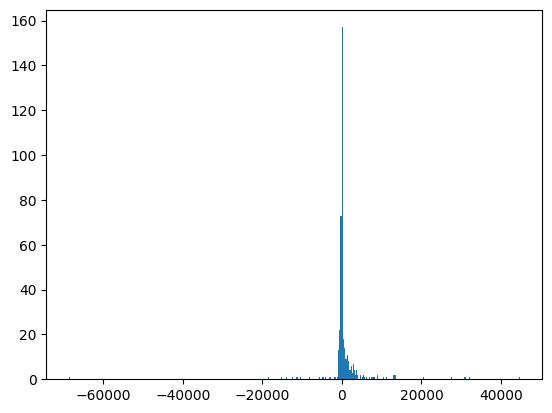

mean value of backward curvature 649.2381095749951 
median value of backward curvature -0.446294325064116 
std value of backward curvature 5650.633305897669 


In [11]:
plt.hist(np.array(df_b['curvature']),bins=400)
plt.show()

print(f"mean value of backward curvature {np.mean(df_b['curvature'])} ")
print(f"median value of backward curvature {np.median(df_b['curvature'])} ")
print(f"std value of backward curvature {np.std(df_b['curvature'])} ")

In [12]:
count_value(df_b['d_curv'])

{'-10e3+': 109,
 '-10e3e2': 89,
 '-10e2e1': 57,
 '-10e1e0': 16,
 '-1_0': 1,
 '1_0': 0,
 '10e0e1': 11,
 '10e1e2': 46,
 '10e2e3': 0,
 '10e3+': 78}

In [13]:
count_value(df_f['d_curv'])

{'-10e3+': 129,
 '-10e3e2': 88,
 '-10e2e1': 38,
 '-10e1e0': 4,
 '-1_0': 2,
 '1_0': 2,
 '10e0e1': 9,
 '10e1e2': 67,
 '10e2e3': 0,
 '10e3+': 259}

In [14]:
count_value(df_s['d_curv'])

{'-10e3+': 10,
 '-10e3e2': 1,
 '-10e2e1': 1,
 '-10e1e0': 0,
 '-1_0': 0,
 '1_0': 0,
 '10e0e1': 0,
 '10e1e2': 0,
 '10e2e3': 0,
 '10e3+': 6}

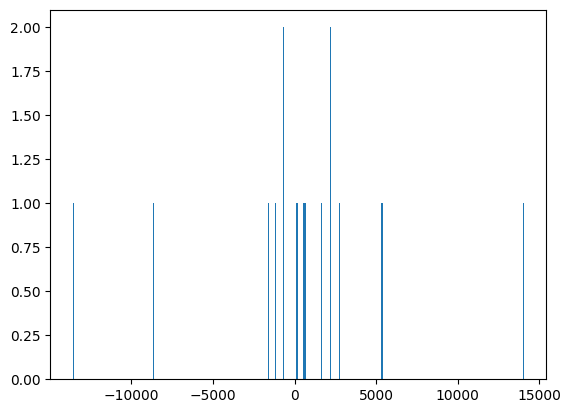

mean value of stable curvature 1743.972617086275 
median value of stable curvature 428.6705356928149 
std value of stable curvature 9644.207993429029 


In [15]:
plt.hist(df_s['curvature'],bins=400)
plt.show()
print(f"mean value of stable curvature {np.mean(df_f['curvature'])} ")
print(f"median value of stable curvature {np.median(df_f['curvature'])} ")
print(f"std value of stable curvature {np.std(df_f['curvature'])} ")

In [16]:
ff1 = '/Users/potato/Downloads/plt59000_flame_iso_c05_flamefront_points.csv'
ff2 = '/Users/potato/Downloads/plt59250_flame_iso_c05_flamefront_points.csv'
dff1 = pd.read_csv(ff1)
dff2 = pd.read_csv(ff2)

In [20]:
tree_59000 = cKDTree(dff1[["y", "z"]].values)

dist_yz, idx_nearest = tree_59000.query(dff2[["y", "z"]].values, k=1)
df_fout = dff2.copy()

df_fout["nearest_idx_59000"] = idx_nearest
df_fout["x_59000_nearest"] = dff1.iloc[idx_nearest]["x"].values
df_fout['d_curv'] = df_fout['curvature'] - dff1.iloc[idx_nearest]["curvature"].values
df_fout["yz_dist"] = dist_yz

dx = df_fout["x_59000_nearest"] - df_fout["x"] 
# negative value: backward
# positive value: forward
# stationary
movement = []
markers= []
for i in range(len(dx)):
    if (dx[i]>0):
        # forward
        movement.append(1)
        markers.append('<')
    elif(dx[i]<0):
        movement.append(-1)
        markers.append('>')
    else:
        movement.append(0)
        markers.append('.')
df_fout["dx"] =  dx
df_fout['displacement']=movement

In [21]:
df_ff = df_fout[df_fout['displacement'] ==1]
df_fb = df_fout[df_fout['displacement'] ==-1]
df_fs = df_fout[df_fout['displacement'] ==0]

In [30]:
count_value(df_fb['curvature'])


{'-10e3+': 2466,
 '-10e3e2': 11855,
 '-10e2e1': 2928,
 '-10e1e0': 336,
 '-1_0': 42,
 '1_0': 45,
 '10e0e1': 319,
 '10e1e2': 2546,
 '10e2e3': 0,
 '10e3+': 14078}

In [31]:
count_value(df_fb['d_curv'])

{'-10e3+': 7150,
 '-10e3e2': 12879,
 '-10e2e1': 1717,
 '-10e1e0': 179,
 '-1_0': 14,
 '1_0': 15,
 '10e0e1': 165,
 '10e1e2': 1591,
 '10e2e3': 0,
 '10e3+': 10905}

In [32]:
count_value(df_fb['curvature'])

{'-10e3+': 2466,
 '-10e3e2': 11855,
 '-10e2e1': 2928,
 '-10e1e0': 336,
 '-1_0': 42,
 '1_0': 45,
 '10e0e1': 319,
 '10e1e2': 2546,
 '10e2e3': 0,
 '10e3+': 14078}

In [33]:
count_value(df_fb['d_curv'])

{'-10e3+': 7150,
 '-10e3e2': 12879,
 '-10e2e1': 1717,
 '-10e1e0': 179,
 '-1_0': 14,
 '1_0': 15,
 '10e0e1': 165,
 '10e1e2': 1591,
 '10e2e3': 0,
 '10e3+': 10905}

In [34]:
count_value(df_fs['curvature'])

{'-10e3+': 48,
 '-10e3e2': 223,
 '-10e2e1': 61,
 '-10e1e0': 7,
 '-1_0': 3,
 '1_0': 1,
 '10e0e1': 10,
 '10e1e2': 59,
 '10e2e3': 0,
 '10e3+': 520}

In [36]:
count_value(df_fs['d_curv'])

{'-10e3+': 208,
 '-10e3e2': 273,
 '-10e2e1': 43,
 '-10e1e0': 2,
 '-1_0': 0,
 '1_0': 0,
 '10e0e1': 4,
 '10e1e2': 55,
 '10e2e3': 0,
 '10e3+': 347}

In [38]:
df_fout

,x,y,z,curvature,y_bin,nearest_idx_59000,x_59000_nearest,d_curv,yz_dist,dx,displacement
0,0.069776,0.000000,0.000000,0.000000,0.000000,0,0.069798,0.000000,0.000000,0.000022,1
1,0.069777,0.000034,0.000000,890.190044,0.000034,1,0.069798,775.419527,0.000000,0.000021,1
2,0.071365,0.000034,0.001572,298.659539,0.000034,242,0.071468,-1900.385615,0.000073,0.000102,1
3,0.071843,0.000035,0.001846,90.952344,0.000035,296,0.072082,-1107.449467,0.000078,0.000239,1
4,0.070068,0.000035,0.000615,3140.101225,0.000035,367,0.070102,2785.547543,0.000096,0.000034,1
...,...,...,...,...,...,...,...,...,...,...,...
76463,0.079454,0.017465,0.004956,1212.754125,0.017465,80437,0.078055,-1392.136369,0.000957,-0.001399,-1
76464,0.078123,0.017465,0.004785,-2.873819,0.017465,80437,0.078055,-2607.764312,0.000786,-0.000068,-1
76465,0.071331,0.017465,0.001641,366.718535,0.017465,80362,0.071365,-593.356837,0.000138,0.000034,1
76466,0.069773,0.017466,0.000000,-195.942744,0.017466,80443,0.069798,-114.646443,0.000000,0.000024,1


In [39]:
df_fout.to_csv('flamefront_full.csv')

In [40]:
pwd

'/Users/potato/Downloads'